# examine overlap in color selection with DESI ELG sample

In [1]:
import numpy as np 
from astropy.table import Table

In [2]:
from astropy.cosmology import Planck18

In [3]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
kota = Table.read('/Users/hahnchanghoon/data/pfs/kota_vi_run21_extra.fits')

In [5]:
print('%i objects' % len(kota))

7449 objects


In [6]:
# pass visual inspection criterion set by DESI Lan et al.(2022)
q_thresh = 3
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh
print('%.2f pass VI' % np.mean(pass_vi))
in_zrange = (kota['z_measured'] > 0.6) & (kota['z_measured'] < 2.4)
print('%.2f pass VI and 0.6 < z < 2.4' % np.mean(pass_vi & in_zrange))
highz = (kota['z_measured'] > 1.6) & (kota['z_measured'] < 2.4)
print('%.4f pass VI and 1.6 < z < 2.4' % np.mean(pass_vi & highz))

0.54 pass VI
0.52 pass VI and 0.6 < z < 2.4
0.0526 pass VI and 1.6 < z < 2.4


In [7]:
g_mag = kota['g_cmodel_mag_2'] - kota['a_g']
r_mag = kota['r_cmodel_mag_2'] - kota['a_r']
i_mag = kota['i_cmodel_mag_2'] - kota['a_i']
z_mag = kota['z_cmodel_mag_2'] - kota['a_z']

In [8]:
# very rough estimate of g-band fiber magnitude used in desi selection 
g_fib_mag = kota['g_cmodel_mag_2'] + 0.5 # roughly >0.5 mag or more of a difference based on quick FIBERFLUX_G vs FLUX_G comparison in DESI ELG_LOP in DR1

## DESI selection

In [9]:
desi_elg_lop = (((g_mag > 20) & (g_f ~ib_mag < 24.1)) & # second selection should be fiber magnitude 
                (0.15 < (r_mag - z_mag)) & 
                ((g_mag - r_mag) < 0.5 * (r_mag - z_mag) + 0.1) &  #Star/low-z cut 
                ((g_mag - r_mag) < -1.2 * (r_mag - z_mag) + 1.3))
desi_elg_vop = (((g_mag > 20) & (g_fib_mag < 24.1)) & # second selection should be fiber magnitude 
                (0.15 < (r_mag - z_mag)) & 
                ((g_mag - r_mag) < 0.5 * (r_mag - z_mag) + 0.1) &  #Star/low-z cut 
                ((g_mag - r_mag) > -1.2 * (r_mag - z_mag) + 1.3) & (g_mag - r_mag < -1.2 * (r_mag - z_mag) + 1.6))

In [10]:
print(np.mean(desi_elg_lop), np.mean(desi_elg_vop))

0.08323264867767485 0.011410927641294134


In [11]:
agg_cut = (((i_mag - z_mag) > 2*(g_mag - r_mag) - 0.4) & ((i_mag - z_mag) < 0.25))

In [12]:
print(np.sum(desi_elg_lop & agg_cut) / np.sum(agg_cut), np.sum(desi_elg_vop & agg_cut) / np.sum(agg_cut))

0.1294663573085847 0.0


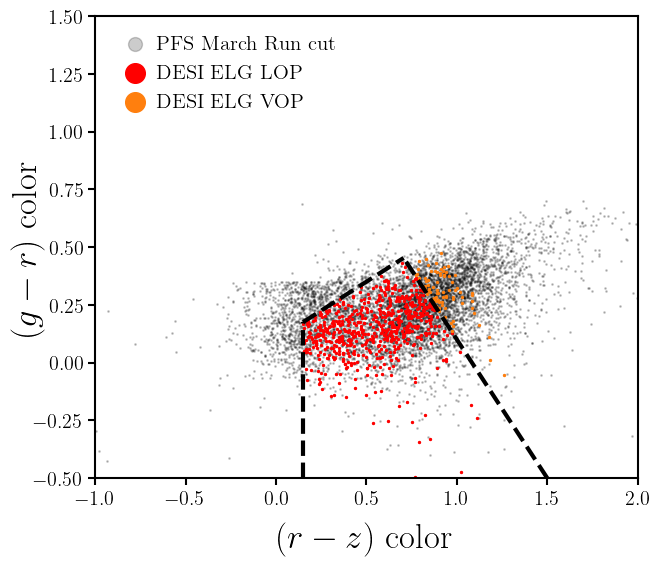

In [30]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (r_mag - z_mag), # (r-z)
    (g_mag - r_mag), # (g-r)
    c='k', s=1, alpha=0.2, label='PFS March Run cut')

sub.scatter(
    (r_mag - z_mag)[desi_elg_lop],
    (g_mag - r_mag)[desi_elg_lop],
    c='r', s=2, label='DESI ELG LOP')

sub.scatter(
    (r_mag - z_mag)[desi_elg_vop],
    (g_mag - r_mag)[desi_elg_vop],
    c='C1', s=2, label='DESI ELG VOP')

sub.plot([0.15, 0.15], [-0.5, 0.175], c='k', ls='--', lw=3)
sub.plot([0.15, 0.7058823529], [0.175, 0.4529411765], c='k', ls='--', lw=3)
sub.plot([1.5, 0.7058823529], [-0.5, 0.4529411765], c='k', ls='--', lw=3)


sub.set_xlim(-1, 2)
sub.set_ylim(-0.5, 1.5)
sub.legend(loc='upper left', fontsize=15, markerscale=10, handletextpad=0)

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(r - z)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)


Text(0.5, 0, '$g$ magnitude')

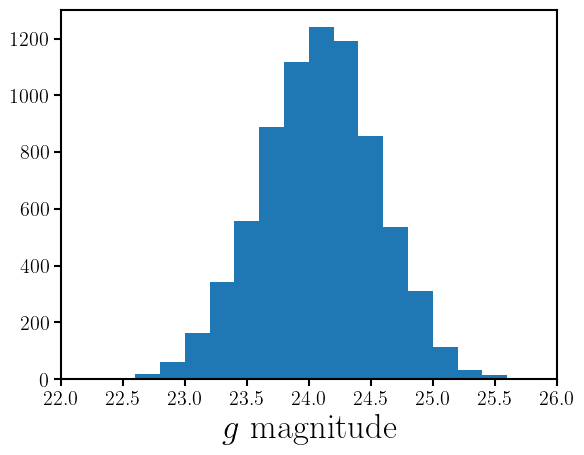

In [45]:
plt.hist(g_mag, range=[22, 26], bins=20)
#plt.hist(g_mag[desi_elg_lop], range=[22, 26], bins=20)
plt.xlim(22., 26.)
plt.ylabel('')
plt.xlabel('$g$ magnitude', fontsize=25)

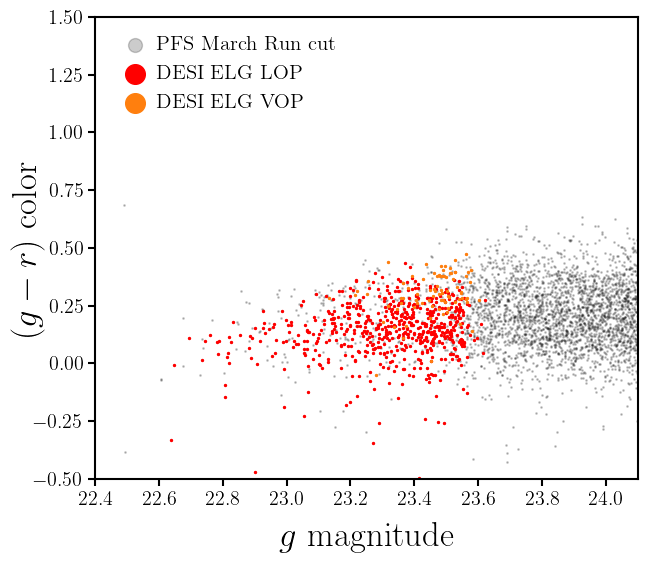

In [33]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag), # (r-z)
    (g_mag - r_mag), # (g-r)
    c='k', s=1, alpha=0.2, label='PFS March Run cut')

sub.scatter(
    (g_mag)[desi_elg_lop],
    (g_mag - r_mag)[desi_elg_lop],
    c='r', s=2, label='DESI ELG LOP')

sub.scatter(
    (g_mag)[desi_elg_vop],
    (g_mag - r_mag)[desi_elg_vop],
    c='C1', s=2, label='DESI ELG VOP')


sub.set_xlim(22.4, 24.1)
sub.set_ylim(-0.5, 1.5)
sub.legend(loc='upper left', fontsize=15, markerscale=10, handletextpad=0)

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$g$ magnitude', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)


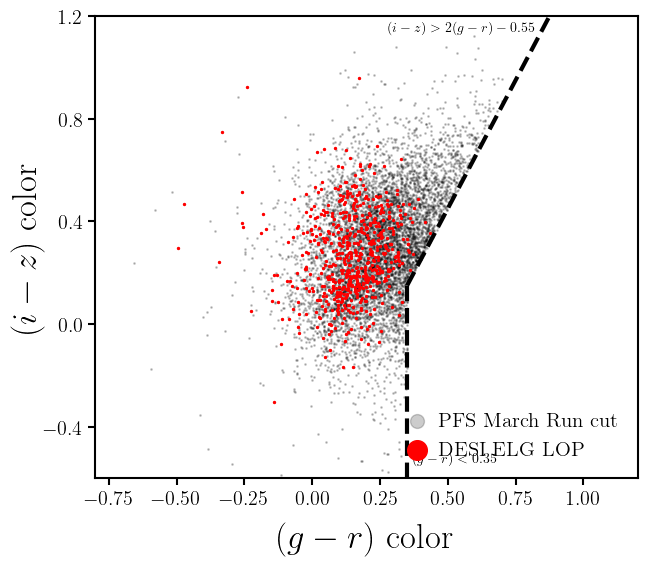

In [46]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2, label='PFS March Run cut')

sub.scatter(
    (g_mag - r_mag)[desi_elg_lop], # (g-r)
    (i_mag - z_mag)[desi_elg_lop], # (i-z)
    c='r', s=2, label='DESI ELG LOP')


#sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge %.1f$' % q_thresh, ha='left', va='top', transform=sub.transAxes, fontsize=25)
#sub.text(0.05, 0.85, r'$0.6 < z < 2.4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])
sub.legend(loc='lower right', fontsize=15, markerscale=10, handletextpad=0)

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
